![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# 2x4 Multimode Interference Coupler (Optical Hybrid)

### 0.1. General libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
import importlib
import upvfab_design_tools

importlib.reload(upvfab_design_tools)
from upvfab_design_tools import MMI_EME, DC_EME


In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## Ancho de las guías de entrada/salida como el ancho del tapper

El tapper tiene un ancho de 1.5 um, por lo que es necesario agregarle a las guias 0.5 um, considerando que ya miden 1 um. 

En este caso vamos a tener en cuenta una longitud de MMI de $\frac{3*L_{pi}}{4}$ = 66.14 um con $L_{pi}$ = 88.19 um. Y no la especificada de 61 um. 

Adicionalmente las entradas se encuentran a -3/8 y 1/8, esto para que esten alineadas con la salida, pues las salidas estarán a -3/8, -1/8, 1/8 y 3/8, esto siguiendo las especificaciónes del artículo titulado: "Miniaturization of 2 × 4 90-Degree Hybrid Optical Couplers". Link: https://pure.tue.nl/ws/portalfiles/portal/301266754/Miniaturization_of_2_4_90_Degree_Hybrid_Optical_Couplers.pdf


In [4]:

# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 7.5 # Student. Body width

# m = MMI_EME(VERBOSE=True)  ## --> Para ver el indice efectivo de cada uno de los modos que se propagan 
m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.wg_width_dw = 0.5 # Ancho adicional de la guia para que sea del tamaño del taper
m.MMI_num_modes = 30 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  88.19169148209537  µm


/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


----------------- ENTRADA INFERIOR -------------------


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1320 [00:00<?, ?it/s]

------- Pameters -------
MMI length 66.1438
MMI length increment -0.1500
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9831
Total OUT power: 0.9460
Excess loss [dB] =  0.1670
------------------------
Power over OUTs:  ['0.2299', '0.2226', '0.2460', '0.2476']
Ratio over OUTs ['0.2430', '0.2353', '0.2600', '0.2617']
Phase over OUTs ['-146.0478', '-12.9882', '169.0789', '-147.9709']
----------------- ENTRADA SUPERIOR -------------------


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1320 [00:00<?, ?it/s]

------- Pameters -------
MMI length 66.1438
MMI length increment -0.1500
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9807
Total OUT power: 0.9588
Excess loss [dB] =  0.0978
------------------------
Power over OUTs:  ['0.2460', '0.2611', '0.2294', '0.2223']
Ratio over OUTs ['0.2565', '0.2723', '0.2393', '0.2318']
Phase over OUTs ['169.0789', '-147.6403', '-143.8498', '-12.9585']


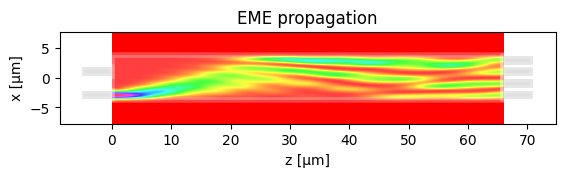

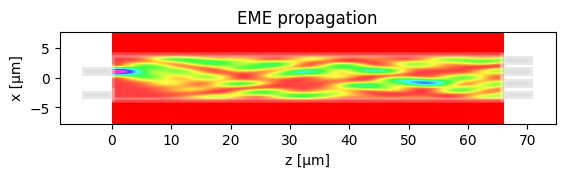

In [22]:
m.n_IN =  2 # STUDENT
m.n_OUT = 4 # STUDENT

dy = 0.1

print("----------------- ENTRADA INFERIOR -------------------")
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-3/8, 1/8]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8,-1/8, 1/8,3/8]) + np.array([-dy,-dy,dy,dy]) # STUDENT

m.L_MMI = 3*L_pi/4
# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.15 # STUDENT

# Run propagation
power1, power_total1,power_in1, phase1=m.propagation()

print("----------------- ENTRADA SUPERIOR -------------------")
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([1/8, -3/8]) + np.array([dy,-dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8,-1/8, 1/8,3/8]) + np.array([-dy,-dy,dy,dy]) # STUDENT

# MMI length (check class slides for type of MMI)
# Run propagation
power2, power_total2,power_in2, phase2=m.propagation()


In [23]:
delta_phase_total=phase1-phase2
print(f'Fase total a la salida del MMI: {delta_phase_total}')

phase_o1_o2=delta_phase_total[1]-delta_phase_total[0]
phase_o3_o4=delta_phase_total[3]-delta_phase_total[2]

print(f'Desfase de las dos primeras salidad del MMI: {np.round(phase_o1_o2,2)}')
print(f'Desfase de las dos ultimas salidad del MMI: {np.round(phase_o3_o4,2)}')

power_in=power_in1+power_in2
power_fin=power1+power2
power_total_final=power_total1+power_total2

Ratio_over_OUTs=power_fin/power_total_final

Loss = 10 * np.log10(power_in / power_total_final)

print("Potencia en las salidas: ", [f"{num:.4f}" for num in power_fin])
print("Relación de potencias de salida:", [f"{num:.4f}" for num in Ratio_over_OUTs])
print("Perdidas de exceso [dB]:", Loss)

Fase total a la salida del MMI: [-315.12678838  134.65210399  312.92870875 -135.01237334]
Desfase de las dos primeras salidad del MMI: 449.78
Desfase de las dos ultimas salidad del MMI: -447.94
Potencia en las salidas:  ['0.4758', '0.4837', '0.4754', '0.4699']
Relación de potencias de salida: ['0.2498', '0.2539', '0.2496', '0.2467']
Perdidas de exceso [dB]: 0.1323109693410829


## Para una longitud del MMI de 61 um 

----------------- ENTRADA INFERIOR -------------------


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1220 [00:00<?, ?it/s]

------- Pameters -------
MMI length 61.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9831
Total OUT power: 0.8098
Excess loss [dB] =  0.8424
------------------------
Power over OUTs:  ['0.1550', '0.2767', '0.1227', '0.2554']
Ratio over OUTs ['0.1914', '0.3417', '0.1515', '0.3154']
Phase over OUTs ['-53.5287', '88.1244', '-74.3776', '-29.6656']
----------------- ENTRADA SUPERIOR -------------------


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1220 [00:00<?, ?it/s]

------- Pameters -------
MMI length 61.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9807
Total OUT power: 0.7272
Excess loss [dB] =  1.2987
------------------------
Power over OUTs:  ['0.1227', '0.2374', '0.0907', '0.2764']
Ratio over OUTs ['0.1687', '0.3265', '0.1248', '0.3801']
Phase over OUTs ['-74.3776', '-10.5423', '-26.4875', '88.0980']


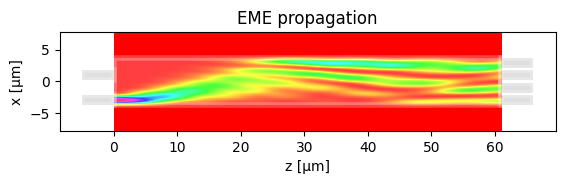

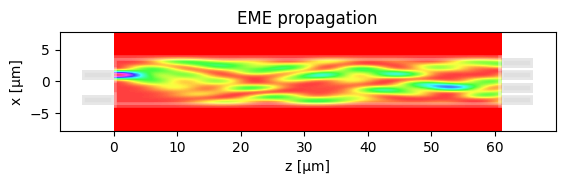

In [ ]:
m.n_IN =  2 # STUDENT
m.n_OUT = 4 # STUDENT

dy = 0.1

print("----------------- ENTRADA INFERIOR -------------------")
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-3/8, 1/8]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8,-1/8, 1/8,3/8]) + np.array([-dy,-dy,dy,dy]) # STUDENT

m.L_MMI = 61
# MMI length (check class slides for type of MMI)
m.dL_MMI = 0 # STUDENT

# Run propagation
power1, power_total1,power_in1, phase1=m.propagation()

print("----------------- ENTRADA SUPERIOR -------------------")
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([1/8, -3/8]) + np.array([dy,-dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8,-1/8, 1/8,3/8]) + np.array([-dy,-dy,dy,dy]) # STUDENT

# MMI length (check class slides for type of MMI)
# Run propagation
power2, power_total2,power_in2, phase2=m.propagation()


In [ ]:
delta_phase_total=phase1-phase2
print(f'Fase total a la salida del MMI: {delta_phase_total}')

phase_o1_o2=delta_phase_total[1]-delta_phase_total[0]
phase_o3_o4=delta_phase_total[3]-delta_phase_total[2]

print(f'Desfase de las dos primeras salidad del MMI: {np.round(phase_o1_o2,2)}')
print(f'Desfase de las dos ultimas salidad del MMI: {np.round(phase_o3_o4,2)}')

power_in=power_in1+power_in2
power_fin=power1+power2
power_total_final=power_total1+power_total2

Ratio_over_OUTs=power_fin/power_total_final

Loss = 10 * np.log10(power_in / power_total_final)

print("Potencia en las salidas: ", [f"{num:.4f}" for num in power_fin])
print("Relación de potencias de salida:", [f"{num:.4f}" for num in Ratio_over_OUTs])
print("Perdidas de exceso [dB]:", Loss)

Fase total a la salida del MMI: [  20.8488909    98.66669029  -47.89010955 -117.7636791 ]
Desfase de las dos primeras salidad del MMI: 77.82
Desfase de las dos ultimas salidad del MMI: -69.87
Power over OUTs:  ['0.2777', '0.5141', '0.2134', '0.5318']
Ratio over OUTs ['0.1807', '0.3345', '0.1388', '0.3460']


Como se observa en los resultados, con la longitud de $\frac{3*L_{pi}}{4}$ obtenemos una diferencia entre las salidas de -90 y 90 grados, mientras que para la longitud de 61 um, obtenemos una diferencia de 70 y -69 grados. 

Adicionalmente en ambos casos, si se halla la diferencia de fase de las salidas (luego de excitar las entradas por separado), no hay una diferencia de fase de 90 grados. 

Tambien observamos como a 61 um de longitud, la relación de potencias se daña, mientras que a $\frac{3*L_{pi}}{4}$ se tiene una buena relación de estas.


## Variación de parámetros para ver que configuración da el mejor resultado en el caso donde la longitud del MMI es $\frac{3*L_{pi}}{4}$

### 1. Variación de la posición de las guias de entrada/salida

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1331 [00:00<?, ?it/s]

------- Pameters -------
MMI length 66.1438
MMI length increment 0.4000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9930
Total OUT power: 0.5873
Excess loss [dB] =  2.2812
------------------------
Power over OUTs:  ['0.1076', '0.0619', '0.2347', '0.1832']
Ratio over OUTs ['0.1831', '0.1053', '0.3996', '0.3119']
Phase over OUTs ['15.5085', '118.0585', '-41.8777', '-18.6840']


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1331 [00:00<?, ?it/s]

...

  0%|          | 0/1331 [00:00<?, ?it/s]

------- Pameters -------
MMI length 66.1438
MMI length increment 0.4000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9676
Total OUT power: 0.8049
Excess loss [dB] =  0.7993
------------------------
Power over OUTs:  ['0.1946', '0.2033', '0.1922', '0.2148']
Ratio over OUTs ['0.2418', '0.2526', '0.2388', '0.2668']
Phase over OUTs ['4.4918', '137.8753', '-38.0586', '5.8786']


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1331 [00:00<?, ?it/s]

------- Pameters -------
MMI length 66.1438
MMI length increment 0.4000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9908
Total OUT power: 0.8268
Excess loss [dB] =  0.7858
------------------------
Power over OUTs:  ['0.2566', '0.2220', '0.1931', '0.1551']
Ratio over OUTs ['0.3104', '0.2685', '0.2335', '0.1876']
Phase over OUTs ['-42.7692', '-4.5482', '11.4134', '133.7802']


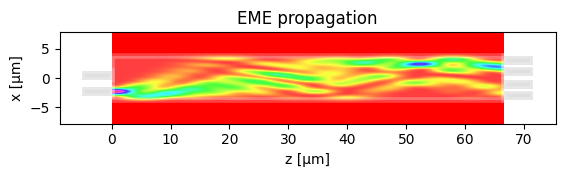

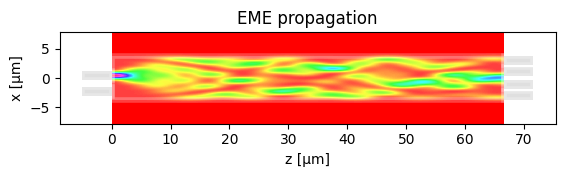

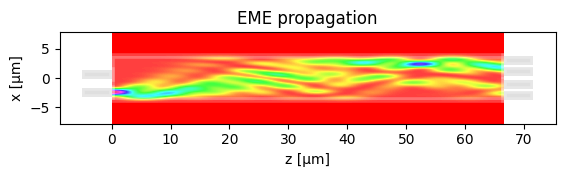

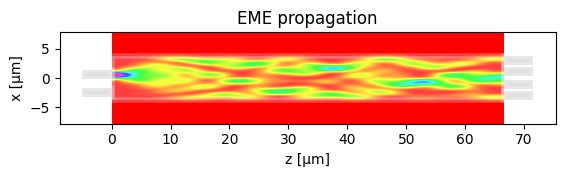

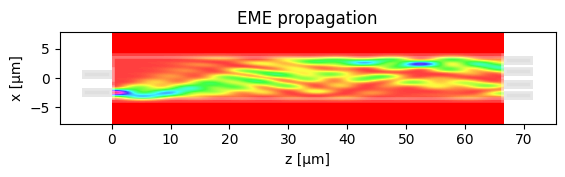

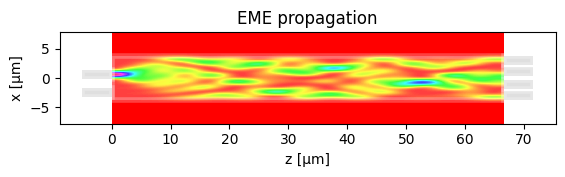

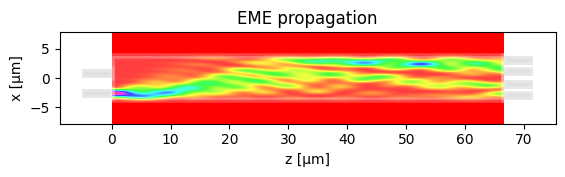

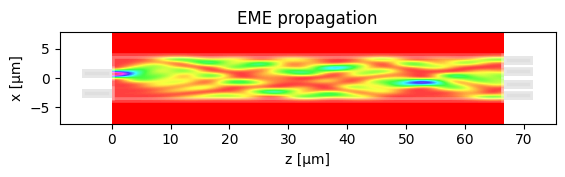

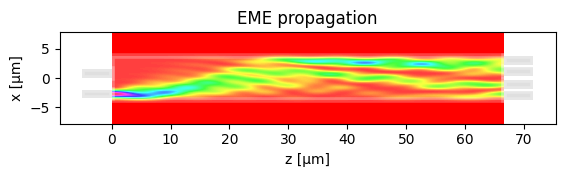

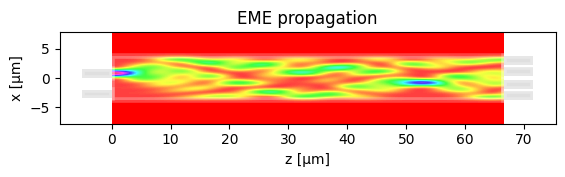

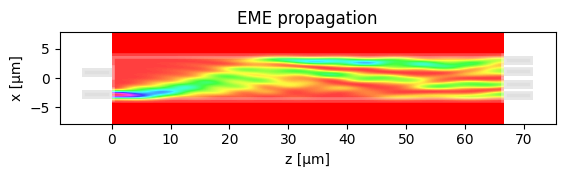

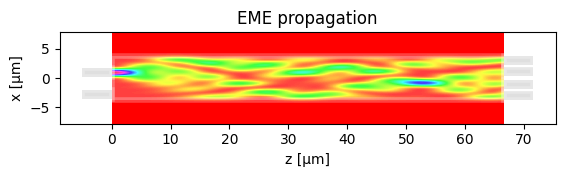

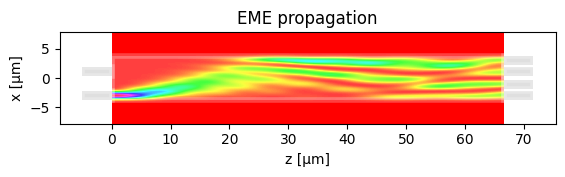

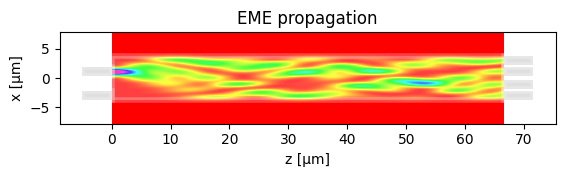

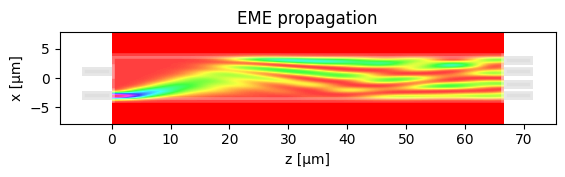

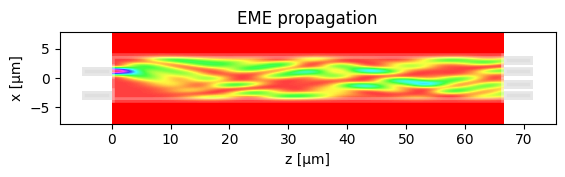

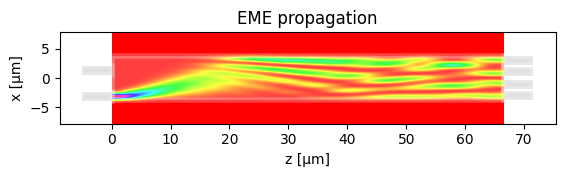

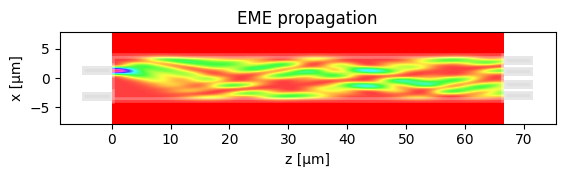

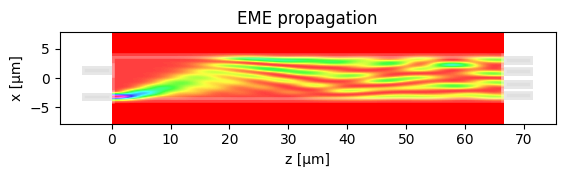

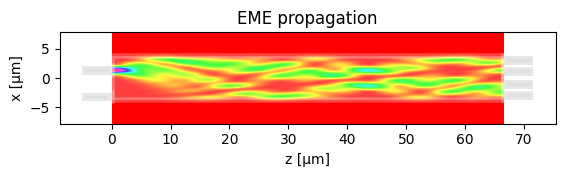

In [66]:
m.n_IN =  2 # STUDENT
m.n_OUT = 4 # STUDENT

array_power_out=[]
array_power_in=[]
array_EL=[]
array_DL_MMI=[]
array_power_out1=[]
array_power_out2=[]
array_power_out3=[]
array_power_out4=[]
array_phase_out1=[]
array_phase_out2=[]
array_phase_out3=[]
array_phase_out4=[]
array_phase_o1_o2=[]
array_phase_o3_o4=[]

m.OUT_WVG_positions = mmi_Width*np.array([-3/8,-1/8, 1/8,3/8]) + np.array([-dy,-dy,dy,dy]) # STUDENT


for i in range(-50,50,10):

    m.L_MMI = 3*L_pi/4
    # MMI length (check class slides for type of MMI)
    dy = i/100 # STUDENT

    # Entrada 1
    m.IN_WVG_positions = mmi_Width*np.array([-3/8, 1/8]) + np.array([-dy,dy]) 
    power1, power_total1,power_in1, phase1=m.propagation()

    # entrada 2
    m.IN_WVG_positions = mmi_Width*np.array([1/8, -3/8]) + np.array([dy,-dy]) 
    power2, power_total2,power_in2, phase2=m.propagation()

    power_total_final=power_total1+power_total2
    power_in=power_in1+power_in2
    Loss = 10 * np.log10(power_in / power_total_final)
    array_power_out.append(power_total_final)
    array_power_in.append(power_in)
    array_EL.append(Loss)
    array_DL_MMI.append(i/100)
    array_power_out1.append((power2[0]+power1[0])/power_total_final)
    array_power_out2.append((power2[1]+power1[1])/power_total_final)
    array_power_out3.append((power2[2]+power1[2])/power_total_final)
    array_power_out4.append((power2[3]+power1[3])/power_total_final)

    delta_phase_total=phase1-phase2
    array_phase_out1.append(delta_phase_total[0])
    array_phase_out2.append(delta_phase_total[1])
    array_phase_out3.append(delta_phase_total[2])
    array_phase_out4.append(delta_phase_total[3])
    array_phase_o1_o2.append(delta_phase_total[1]-delta_phase_total[0])
    array_phase_o3_o4.append(delta_phase_total[3]-delta_phase_total[2])

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_37648/1627670115.py:6: SyntaxWarning: invalid escape sequence '\m'
  axs[0,0].set_xlabel('dy ($\mu$m)')
/tmp/ipykernel_37648/1627670115.py:16: SyntaxWarning: invalid escape sequence '\m'
  axs[0,1].set_xlabel('dy ($\mu$m)')
/tmp/ipykernel_37648/1627670115.py:26: SyntaxWarning: invalid escape sequence '\m'
  axs[1,0].set_xlabel('dy ($\mu$m)')
/tmp/ipykernel_37648/1627670115

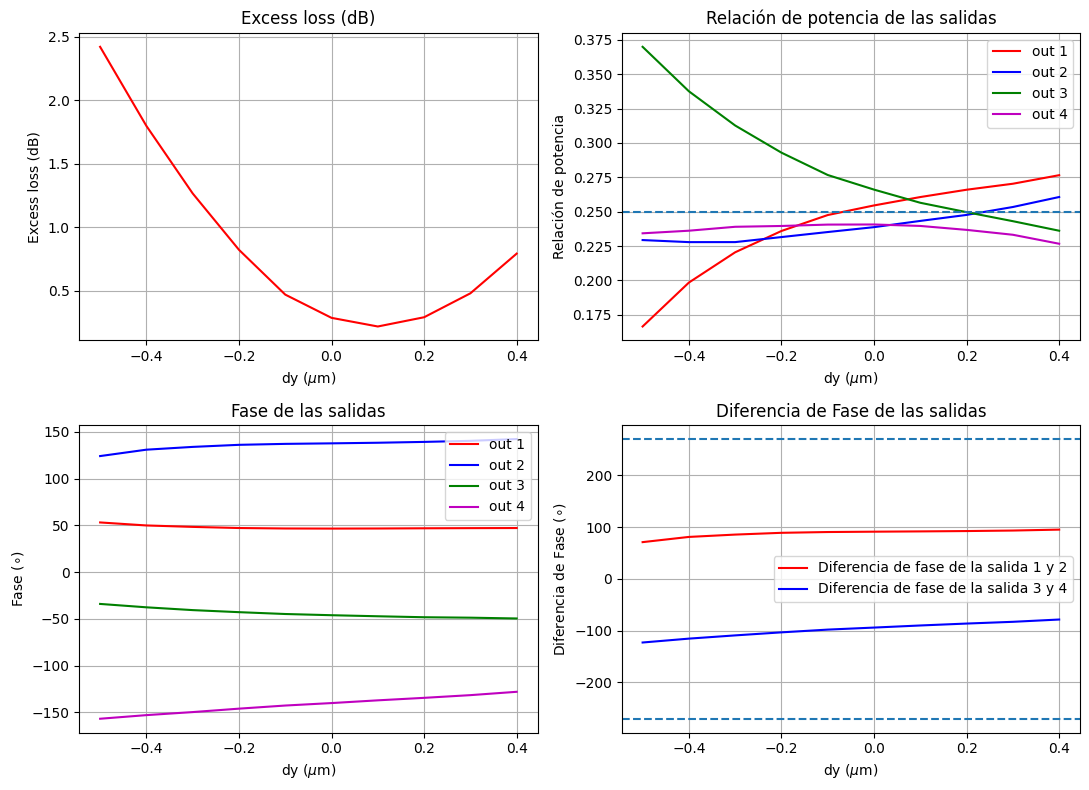

In [68]:

fig, axs = plt.subplots(2, 2, figsize=(11, 8))


axs[0,0].plot(array_DL_MMI, array_EL, 'r') 
axs[0,0].set_title('Excess loss (dB)')
axs[0,0].set_xlabel('dy ($\mu$m)')
axs[0,0].set_ylabel('Excess loss (dB)')
axs[0,0].grid(True)

axs[0,1].plot(array_DL_MMI, array_power_out1, 'r',label='out 1') 
axs[0,1].plot(array_DL_MMI, array_power_out2, 'b',label='out 2')
axs[0,1].plot(array_DL_MMI, array_power_out3, 'g',label='out 3')
axs[0,1].plot(array_DL_MMI, array_power_out4, 'm',label='out 4')
axs[0,1].axhline(y=0.25, linestyle='--', linewidth=1.5)
axs[0,1].set_title('Relación de potencia de las salidas')
axs[0,1].set_xlabel('dy ($\mu$m)')
axs[0,1].set_ylabel('Relación de potencia')
axs[0,1].legend()
axs[0,1].grid(True)

axs[1,0].plot(array_DL_MMI, array_phase_out1, 'r',label='out 1') 
axs[1,0].plot(array_DL_MMI, array_phase_out2, 'b',label='out 2')
axs[1,0].plot(array_DL_MMI, array_phase_out3, 'g',label='out 3')
axs[1,0].plot(array_DL_MMI, array_phase_out4, 'm',label='out 4')
axs[1,0].set_title('Fase de las salidas')
axs[1,0].set_xlabel('dy ($\mu$m)')
axs[1,0].set_ylabel('Fase ($\circ$)')
axs[1,0].legend()
axs[1,0].grid(True)

axs[1,1].plot(array_DL_MMI, array_phase_o1_o2, 'r',label='Diferencia de fase de la salida 1 y 2') 
axs[1,1].plot(array_DL_MMI, array_phase_o3_o4, 'b',label='Diferencia de fase de la salida 3 y 4')
axs[1,1].axhline(y=270, linestyle='--', linewidth=1.5)
axs[1,1].axhline(y=-270, linestyle='--', linewidth=1.5)
axs[1,1].set_title('Diferencia de Fase de las salidas')
axs[1,1].set_xlabel('dy ($\mu$m)')
axs[1,1].set_ylabel('Diferencia de Fase ($\circ$)')
axs[1,1].legend()
axs[1,1].grid(True)


plt.tight_layout()

plt.show()

Deacuerdo a las gráficas de escoge 0.1 de corrimiento en la posición de las guias de onda, ya que es en punto donde tenemos menores perdidas y la relación de potencias no es tan mala. 

### 2. variación de la longitud del MMI

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1313 [00:00<?, ?it/s]

------- Pameters -------
MMI length 66.1438
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9831
Total OUT power: 0.9504
Excess loss [dB] =  0.1468
------------------------
Power over OUTs:  ['0.2253', '0.2286', '0.2423', '0.2542']
Ratio over OUTs ['0.2370', '0.2405', '0.2550', '0.2675']
Phase over OUTs ['-12.9500', '119.8955', '-56.6119', '-13.8588']


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1313 [00:00<?, ?it/s]

...

  0%|          | 0/1331 [00:00<?, ?it/s]

------- Pameters -------
MMI length 66.1438
MMI length increment 0.4000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9831
Total OUT power: 0.9345
Excess loss [dB] =  0.2204
------------------------
Power over OUTs:  ['0.2368', '0.2127', '0.2499', '0.2351']
Ratio over OUTs ['0.2534', '0.2276', '0.2674', '0.2516']
Phase over OUTs ['4.6778', '138.3168', '-42.0877', '1.3096']


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1331 [00:00<?, ?it/s]

------- Pameters -------
MMI length 66.1438
MMI length increment 0.4000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9807
Total OUT power: 0.9327
Excess loss [dB] =  0.2177
------------------------
Power over OUTs:  ['0.2499', '0.2416', '0.2290', '0.2123']
Ratio over OUTs ['0.2679', '0.2590', '0.2455', '0.2276']
Phase over OUTs ['-42.0877', '-0.1719', '5.0225', '138.3429']


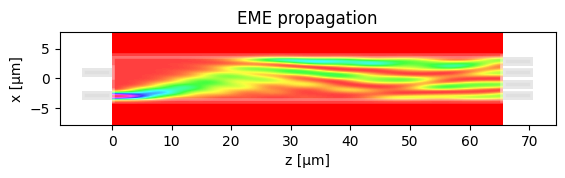

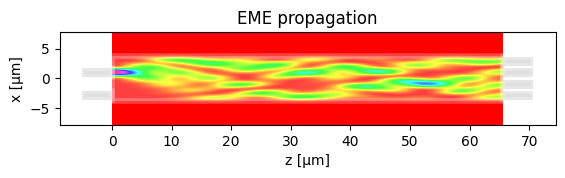

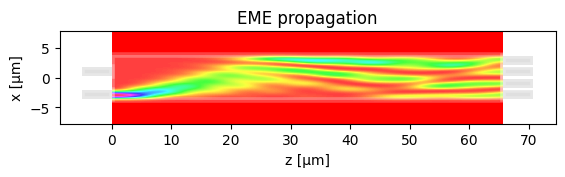

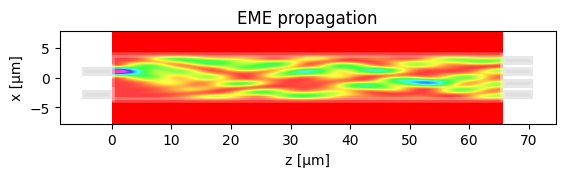

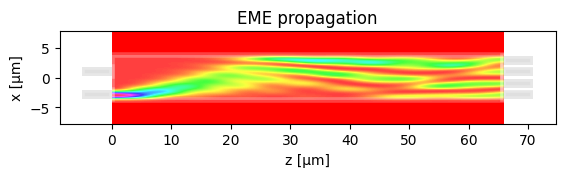

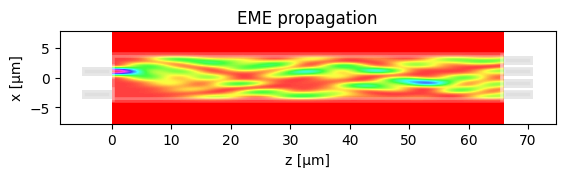

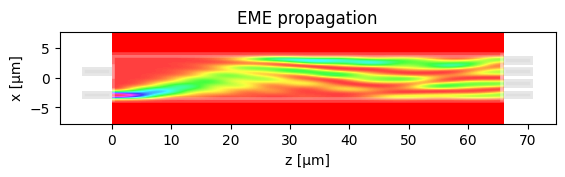

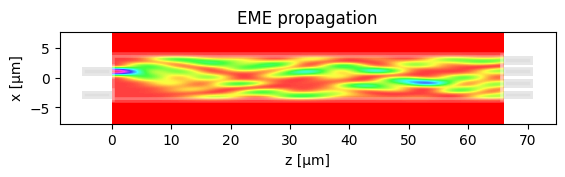

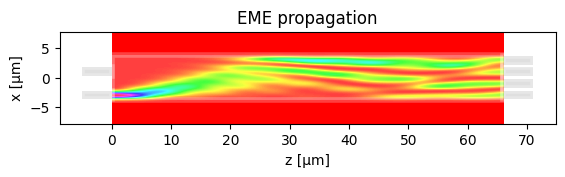

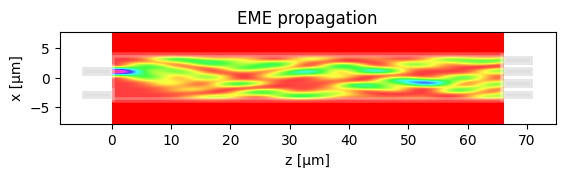

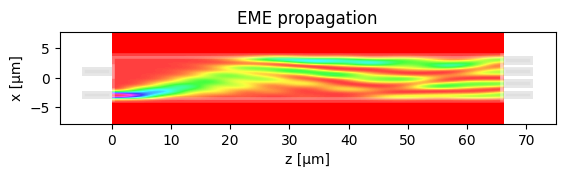

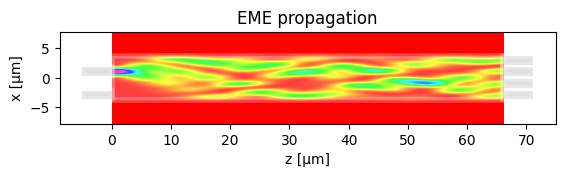

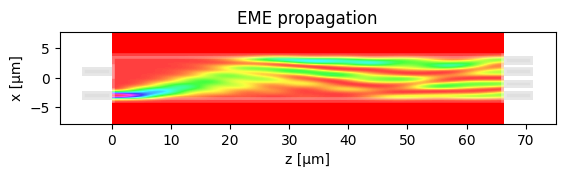

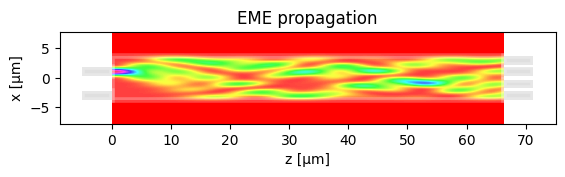

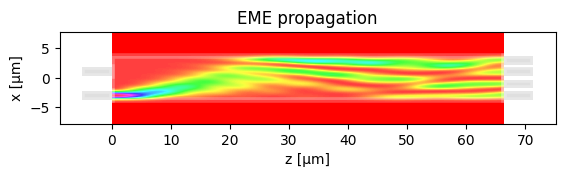

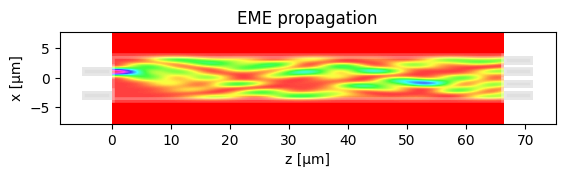

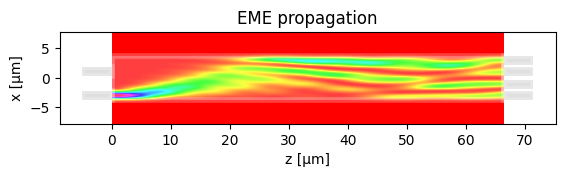

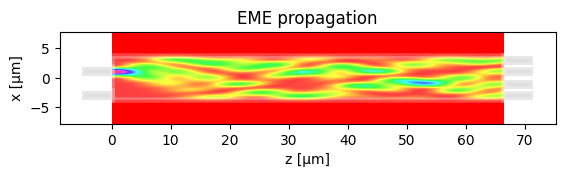

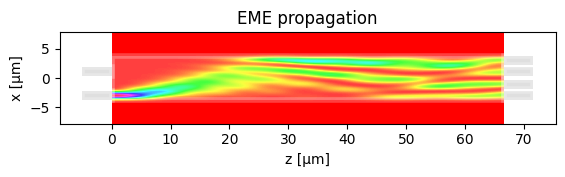

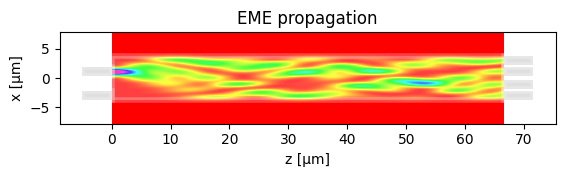

In [71]:
m.n_IN =  2 # STUDENT
m.n_OUT = 4 # STUDENT

array_power_out=[]
array_power_in=[]
array_EL=[]
array_DL_MMI=[]
array_power_out1=[]
array_power_out2=[]
array_power_out3=[]
array_power_out4=[]
array_phase_out1=[]
array_phase_out2=[]
array_phase_out3=[]
array_phase_out4=[]
array_phase_o1_o2=[]
array_phase_o3_o4=[]
dy = 0.1
m.OUT_WVG_positions = mmi_Width*np.array([-3/8,-1/8, 1/8,3/8]) + np.array([-dy,-dy,dy,dy]) # STUDENT


for i in range(-50,50,10):

    m.L_MMI = 3*L_pi/4
    # MMI length (check class slides for type of MMI)
    m.dL_MMI = i/100 # STUDENT

    # Entrada 1
    m.IN_WVG_positions = mmi_Width*np.array([-3/8, 1/8]) + np.array([-dy,dy]) 
    power1, power_total1,power_in1, phase1=m.propagation()

    # entrada 2
    m.IN_WVG_positions = mmi_Width*np.array([1/8, -3/8]) + np.array([dy,-dy]) 
    power2, power_total2,power_in2, phase2=m.propagation()

    power_total_final=power_total1+power_total2
    power_in=power_in1+power_in2
    Loss = 10 * np.log10(power_in / power_total_final)
    array_power_out.append(power_total_final)
    array_power_in.append(power_in)
    array_EL.append(Loss)
    array_DL_MMI.append(i/100)
    array_power_out1.append((power2[0]+power1[0])/power_total_final)
    array_power_out2.append((power2[1]+power1[1])/power_total_final)
    array_power_out3.append((power2[2]+power1[2])/power_total_final)
    array_power_out4.append((power2[3]+power1[3])/power_total_final)

    delta_phase_total=phase1-phase2
    array_phase_out1.append(delta_phase_total[0])
    array_phase_out2.append(delta_phase_total[1])
    array_phase_out3.append(delta_phase_total[2])
    array_phase_out4.append(delta_phase_total[3])
    array_phase_o1_o2.append(delta_phase_total[1]-delta_phase_total[0])
    array_phase_o3_o4.append(delta_phase_total[3]-delta_phase_total[2])

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_37648/50205561.py:6: SyntaxWarning: invalid escape sequence '\m'
  axs[0,0].set_xlabel('dL_MMI ($\mu$m)')
/tmp/ipykernel_37648/50205561.py:16: SyntaxWarning: invalid escape sequence '\m'
  axs[0,1].set_xlabel('dL_MMI ($\mu$m)')
/tmp/ipykernel_37648/50205561.py:26: SyntaxWarning: invalid escape sequence '\m'
  axs[1,0].set_xlabel('dL_MMI ($\mu$m)')
/tmp/ipykernel_37648/5020

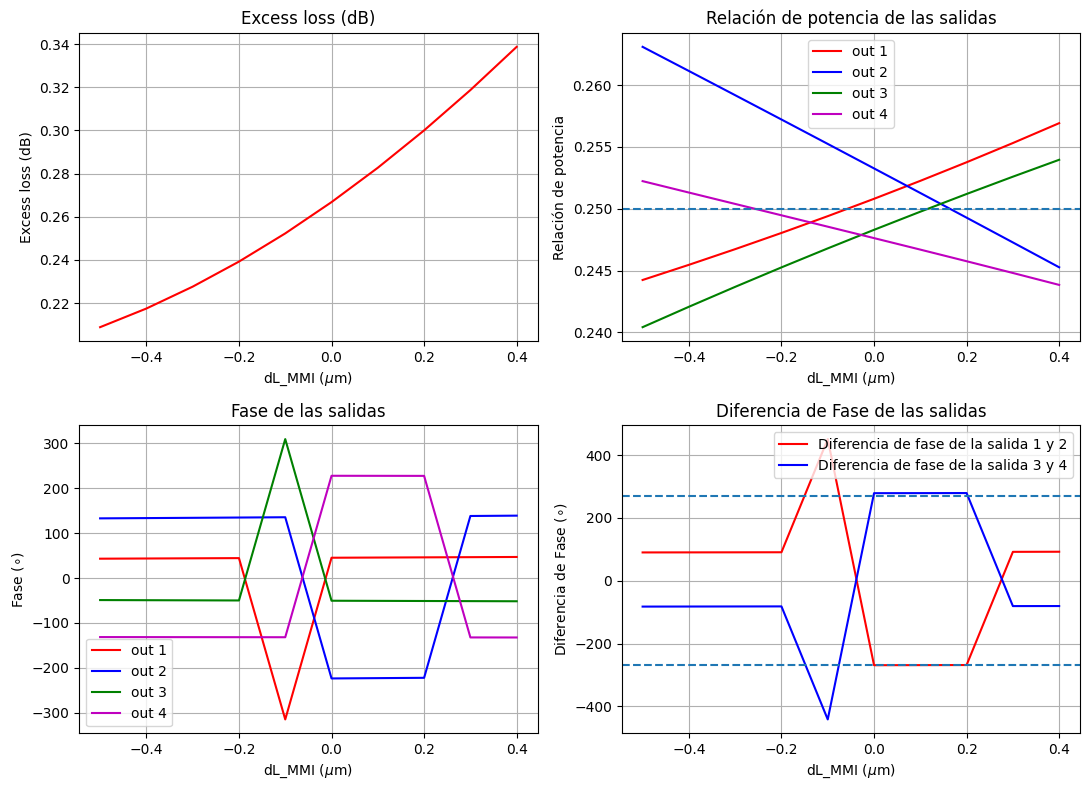

In [70]:

fig, axs = plt.subplots(2, 2, figsize=(11, 8))


axs[0,0].plot(array_DL_MMI, array_EL, 'r') 
axs[0,0].set_title('Excess loss (dB)')
axs[0,0].set_xlabel('dL_MMI ($\mu$m)')
axs[0,0].set_ylabel('Excess loss (dB)')
axs[0,0].grid(True)

axs[0,1].plot(array_DL_MMI, array_power_out1, 'r',label='out 1') 
axs[0,1].plot(array_DL_MMI, array_power_out2, 'b',label='out 2')
axs[0,1].plot(array_DL_MMI, array_power_out3, 'g',label='out 3')
axs[0,1].plot(array_DL_MMI, array_power_out4, 'm',label='out 4')
axs[0,1].axhline(y=0.25, linestyle='--', linewidth=1.5)
axs[0,1].set_title('Relación de potencia de las salidas')
axs[0,1].set_xlabel('dL_MMI ($\mu$m)')
axs[0,1].set_ylabel('Relación de potencia')
axs[0,1].legend()
axs[0,1].grid(True)

axs[1,0].plot(array_DL_MMI, array_phase_out1, 'r',label='out 1') 
axs[1,0].plot(array_DL_MMI, array_phase_out2, 'b',label='out 2')
axs[1,0].plot(array_DL_MMI, array_phase_out3, 'g',label='out 3')
axs[1,0].plot(array_DL_MMI, array_phase_out4, 'm',label='out 4')
axs[1,0].set_title('Fase de las salidas')
axs[1,0].set_xlabel('dL_MMI ($\mu$m)')
axs[1,0].set_ylabel('Fase ($\circ$)')
axs[1,0].legend()
axs[1,0].grid(True)

axs[1,1].plot(array_DL_MMI, array_phase_o1_o2, 'r',label='Diferencia de fase de la salida 1 y 2') 
axs[1,1].plot(array_DL_MMI, array_phase_o3_o4, 'b',label='Diferencia de fase de la salida 3 y 4')
axs[1,1].axhline(y=270, linestyle='--', linewidth=1.5)
axs[1,1].axhline(y=-270, linestyle='--', linewidth=1.5)
axs[1,1].set_title('Diferencia de Fase de las salidas')
axs[1,1].set_xlabel('dL_MMI ($\mu$m)')
axs[1,1].set_ylabel('Diferencia de Fase ($\circ$)')
axs[1,1].legend()
axs[1,1].grid(True)


plt.tight_layout()

plt.show()

Teniendo en cuenta el anterior gráfico, podemos decir que el mejor valor es reducir la longitud del MMI en 0.18 um. 